In [1]:
# %% ============================================================
# CELL 1: Imports & Configuration
# ===============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import gc
import time
from pathlib import Path
from scipy.stats import spearmanr
 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
 
warnings.filterwarnings("ignore")
 
DATA_PATH = Path("data")
 
# ── Hyperparameters ───────────────────────────────────────────

SEQUENCE_LENGTH  = 20
HIDDEN_SIZE      = 32
NUM_LAYERS       = 1
DROPOUT          = 0.4
LEARNING_RATE    = 5e-4
WEIGHT_DECAY     = 1e-3
EPOCHS           = 200
BATCH_SIZE       = 64
PATIENCE         = 35
N_PCA            = 100
N_SEEDS          = 5
TRAIN_END        = 1600
VAL_END          = 1827
RANK_LOSS_ALPHA  = 0.7
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [2]:
# %% ============================================================
# CELL 2: Load Data
# ===============================================================
train        = pd.read_csv(DATA_PATH / "train.csv").sort_values("date_id").reset_index(drop=True)
train_labels = pd.read_csv(DATA_PATH / "train_labels.csv").sort_values("date_id").reset_index(drop=True)
test         = pd.read_csv(DATA_PATH / "test.csv").sort_values("date_id").reset_index(drop=True)
ground_truth = pd.read_csv(DATA_PATH / "test_ground_truth.csv").sort_values("date_id").reset_index(drop=True)
target_pairs = pd.read_csv(DATA_PATH / "target_pairs.csv")
 
if "is_scored" in test.columns:
    is_scored = test["is_scored"].copy()
    test = test.drop(columns=["is_scored"])
 
feature_cols = [c for c in train.columns if c != "date_id"]
target_cols  = [c for c in train_labels.columns if c != "date_id"]
 
lag_groups = {}
for lag in [1, 2, 3, 4]:
    lag_groups[lag] = target_pairs.loc[target_pairs["lag"] == lag, "target"].tolist()
 
print(f"Train: {train.shape}, Test: {test.shape}")
print(f"Features: {len(feature_cols)}, Targets: {len(target_cols)}")
print(f"Train period: 0-{TRAIN_END-1}, Val: {TRAIN_END}-{VAL_END-1}, Test: {VAL_END}-1960")

Train: (1961, 558), Test: (134, 558)
Features: 557, Targets: 424
Train period: 0-1599, Val: 1600-1826, Test: 1827-1960


In [3]:
# %% ============================================================
# CELL 3: Feature Engineering
# ===============================================================
def get_pair_assets(pair_str):
    if " - " in pair_str:
        a, b = pair_str.split(" - ", 1)
        return a.strip(), b.strip()
    return pair_str.strip(), None
 
 
def engineer_features(df, target_pairs_df):
    """Build features: returns + pair spreads + rolling stats."""
    feat = pd.DataFrame({"date_id": df["date_id"].values})
 
    all_assets = set()
    for _, row in target_pairs_df.iterrows():
        a, b = get_pair_assets(row["pair"])
        all_assets.add(a)
        if b:
            all_assets.add(b)
    target_assets = sorted([c for c in all_assets if c in df.columns])
 
    for col in target_assets:
        for h in [1, 2, 5, 10, 20]:
            feat[f"{col}_ret{h}"] = df[col].pct_change(h)
 
    for col in target_assets:
        ret1 = df[col].pct_change(1)
        feat[f"{col}_vol5"]  = ret1.rolling(5).std()
        feat[f"{col}_vol20"] = ret1.rolling(20).std()
        feat[f"{col}_mom5"]  = ret1.rolling(5).mean()
        feat[f"{col}_mom20"] = ret1.rolling(20).mean()
 
    pairs_done = set()
    for _, row in target_pairs_df.iterrows():
        a, b = get_pair_assets(row["pair"])
        if b is None:
            continue
        key = f"{a}__{b}"
        if key in pairs_done or a not in df.columns or b not in df.columns:
            continue
        pairs_done.add(key)
        spread = df[a] - df[b]
        feat[f"{key}_sret1"] = spread.pct_change(1)
        feat[f"{key}_sret5"] = spread.pct_change(5)
        feat[f"{key}_relmom5"] = df[a].pct_change(5) - df[b].pct_change(5)
 
    feat = feat.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return feat
 
 
print("Engineering features...")
t0 = time.time()
train_feat = engineer_features(train, target_pairs)
eng_cols = [c for c in train_feat.columns if c != "date_id"]
print(f"Done in {time.time()-t0:.1f}s — {len(eng_cols)} raw features")

Engineering features...
Done in 3.6s — 2064 raw features


In [4]:
# %% ============================================================
# CELL 4: PCA Compression + Scaling
# ===============================================================
scaler = RobustScaler()
train_mask = train_feat["date_id"] < TRAIN_END
 
scaler.fit(train_feat.loc[train_mask, eng_cols])
train_scaled = np.clip(scaler.transform(train_feat[eng_cols]).astype(np.float32), -5, 5)
 
pca = PCA(n_components=N_PCA)
pca.fit(train_scaled[train_mask.values])
print(f"PCA({N_PCA}) explained variance: {pca.explained_variance_ratio_.sum():.4f}")
 
train_pca = pca.transform(train_scaled).astype(np.float32)
train_label_arr = train_labels[target_cols].values.astype(np.float32)
 
print(f"Final feature shape — Train: {train_pca.shape}")

PCA(100) explained variance: 0.9389
Final feature shape — Train: (1961, 100)


In [5]:
# %% ============================================================
# CELL 5: Dataset
# ===============================================================
class CommodityDataset(Dataset):
    def __init__(self, features, targets, seq_len):
        self.features = features
        self.targets  = targets
        self.seq_len  = seq_len
 
    def __len__(self):
        return len(self.features) - self.seq_len
 
    def __getitem__(self, idx):
        x = self.features[idx : idx + self.seq_len]
        y = self.targets[idx + self.seq_len]
        return torch.from_numpy(x), torch.from_numpy(y)

In [6]:
# %% ============================================================
# CELL 6: LSTM Model
# ===============================================================
class LSTMRanker(nn.Module):
    def __init__(self, n_features, n_targets, hidden_size=32,
                 num_layers=1, dropout=0.4):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.norm = nn.LayerNorm(hidden_size)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, n_targets),
        )
 
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last = lstm_out[:, -1, :]
        last = self.norm(last)
        return self.head(last)

In [7]:
# %% ============================================================
# CELL 7: Competition Metric
# ===============================================================
def competition_score(pred_df, gt_df, target_cols, silent=False):
    pred = pred_df[target_cols].copy()
    gt   = gt_df[target_cols].copy()
    daily_corrs = []
    for i in range(len(pred)):
        gt_row = gt.iloc[i]
        pred_row = pred.iloc[i]
        valid = gt_row.notna()
        if valid.sum() < 2:
            continue
        gt_valid = gt_row[valid]
        pred_valid = pred_row[valid]
        if gt_valid.std(ddof=0) == 0 or pred_valid.std(ddof=0) == 0:
            continue
        corr = np.corrcoef(
            pred_valid.rank(method="average"),
            gt_valid.rank(method="average")
        )[0, 1]
        daily_corrs.append(corr)
    daily_corrs = np.array(daily_corrs)
    if len(daily_corrs) == 0 or daily_corrs.std(ddof=0) == 0:
        return 0.0, daily_corrs
    sharpe = daily_corrs.mean() / daily_corrs.std(ddof=0)
    if not silent:
        print(f"  Daily rank corr: mean={daily_corrs.mean():.4f}, "
              f"std={daily_corrs.std():.4f}, Sharpe={sharpe:.4f}, "
              f"days={len(daily_corrs)}")
    return sharpe, daily_corrs

In [8]:
# %% ============================================================
# CELL 8: Training Function (pure MSE, early stop on val Sharpe)
# ===============================================================
def predict_all(model, features, seq_len, device):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(seq_len, len(features)):
            x = features[i - seq_len : i]
            x_t = torch.FloatTensor(x).unsqueeze(0).to(device)
            pred = model(x_t).cpu().numpy()[0]
            preds.append(pred)
    return np.array(preds)
 
 
def train_model(model, train_features, train_targets, val_features, val_targets,
                val_date_ids, seq_len, epochs, lr, weight_decay, patience,
                alpha, device, label=""):
    """
    Training with blended loss (alpha * ranking + (1-alpha) * MSE).
    When alpha=0.0, this is pure MSE.
    Early stops on validation Sharpe (competition metric).
    """
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
 
    train_ds = CommodityDataset(train_features, train_targets, seq_len)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
 
    best_sharpe = -float("inf")
    best_state = None
    wait = 0
    history = {"train_loss": [], "val_sharpe": []}
 
    for epoch in range(epochs):
        # Train
        model.train()
        epoch_losses = []
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            pred = model(x_batch)
 
            # MSE loss (ignoring NaN targets)
            mask = ~torch.isnan(y_batch)
            if mask.sum() == 0:
                continue
            loss = nn.functional.mse_loss(pred[mask], y_batch[mask])
 
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_losses.append(loss.item())
 
        scheduler.step()
        train_loss = np.mean(epoch_losses) if epoch_losses else float("inf")
        history["train_loss"].append(train_loss)
 
        # Validate using competition metric
        val_preds = predict_all(model, val_features, seq_len, device)
        val_pred_df = pd.DataFrame(val_preds, columns=target_cols)
        val_pred_df.insert(0, "date_id", val_date_ids)
        val_gt_df = train_labels[train_labels["date_id"].isin(val_date_ids)].reset_index(drop=True)
        val_sharpe, _ = competition_score(val_pred_df, val_gt_df, target_cols, silent=True)
        history["val_sharpe"].append(val_sharpe)
 
        # Early stopping on Sharpe
        if val_sharpe > best_sharpe:
            best_sharpe = val_sharpe
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
            marker = " ★"
        else:
            wait += 1
            marker = ""
 
        if (epoch + 1) % 10 == 0 or marker:
            print(f"  [{label}] Epoch {epoch+1:3d}/{epochs}  "
                  f"train={train_loss:.6f}  val_sharpe={val_sharpe:.4f}{marker}")
 
        if wait >= patience:
            print(f"  [{label}] Early stopping at epoch {epoch+1}")
            break
 
    model.load_state_dict(best_state)
    model.to(device)
    print(f"  [{label}] Best val Sharpe: {best_sharpe:.4f}")
    return model, history

In [9]:
# %% ============================================================
# CELL 9: Train Ensemble
# ===============================================================
val_start_idx = int((train_feat["date_id"] >= TRAIN_END).values.argmax())
val_end_idx   = int((train_feat["date_id"] >= VAL_END).values.argmax())
 
train_features = train_pca[:val_start_idx]
train_targets  = train_label_arr[:val_start_idx]
 
val_features = train_pca[val_start_idx - SEQUENCE_LENGTH : val_end_idx]
val_targets  = train_label_arr[val_start_idx - SEQUENCE_LENGTH : val_end_idx]
val_date_ids = train_feat.iloc[val_start_idx:val_end_idx]["date_id"].values
 
print(f"Train samples: {len(train_features) - SEQUENCE_LENGTH}")
print(f"Val dates: {val_date_ids.min()}-{val_date_ids.max()} ({len(val_date_ids)} days)")
print(f"PCA features: {N_PCA}")
print()
 
models = []
histories = []
 
for seed_idx in range(N_SEEDS):
    seed = 42 + seed_idx * 111
    torch.manual_seed(seed)
    np.random.seed(seed)
 
    print(f"\n{'='*55}")
    print(f"Seed {seed_idx+1}/{N_SEEDS} (seed={seed})")
    print(f"{'='*55}")
 
    model = LSTMRanker(
        n_features=N_PCA,
        n_targets=len(target_cols),
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
    ).to(DEVICE)
 
    if seed_idx == 0:
        print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
 
    model, hist = train_model(
        model=model,
        train_features=train_features,
        train_targets=train_targets,
        val_features=val_features,
        val_targets=val_targets,
        val_date_ids=val_date_ids,
        seq_len=SEQUENCE_LENGTH,
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        patience=PATIENCE,
        alpha=RANK_LOSS_ALPHA,
        device=DEVICE,
        label=f"s{seed_idx}",
    )
 
    models.append(model)
    histories.append(hist)
 
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Train samples: 1580
Val dates: 1600-1826 (227 days)
PCA features: 100


Seed 1/5 (seed=42)
Parameters: 32,264
  [s0] Epoch   1/200  train=0.071446  val_sharpe=0.0092 ★
  [s0] Epoch  10/200  train=0.005758  val_sharpe=-0.0305
  [s0] Epoch  20/200  train=0.002723  val_sharpe=-0.0074
  [s0] Epoch  27/200  train=0.002141  val_sharpe=0.0121 ★
  [s0] Epoch  29/200  train=0.002016  val_sharpe=0.0141 ★
  [s0] Epoch  30/200  train=0.001968  val_sharpe=0.0066
  [s0] Epoch  32/200  train=0.001867  val_sharpe=0.0159 ★
  [s0] Epoch  34/200  train=0.001796  val_sharpe=0.0176 ★
  [s0] Epoch  35/200  train=0.001731  val_sharpe=0.0183 ★
  [s0] Epoch  36/200  train=0.001693  val_sharpe=0.0271 ★
  [s0] Epoch  40/200  train=0.001582  val_sharpe=0.0259
  [s0] Epoch  41/200  train=0.001554  val_sharpe=0.0450 ★
  [s0] Epoch  43/200  train=0.001499  val_sharpe=0.0490 ★
  [s0] Epoch  45/200  train=0.001465  val_sharpe=0.0501 ★
  [s0] Epoch  47/200  train=0.001400  val_sharpe=0.0549 ★
  [s0] Epoch  50/200  trai

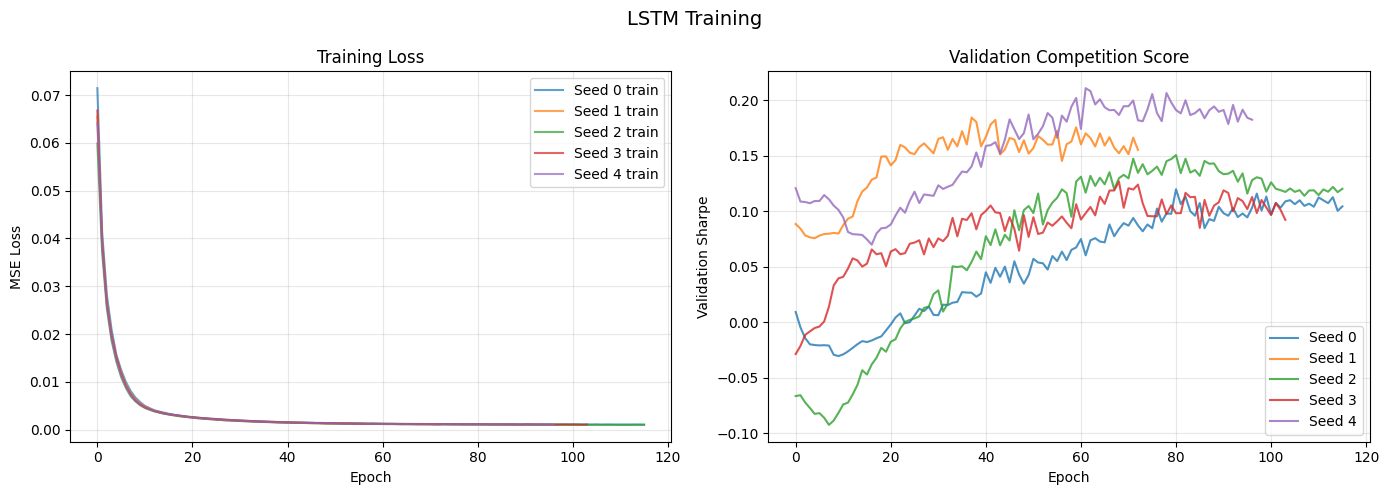

In [10]:
# %% ============================================================
# CELL 10: Plot Training
# ===============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
for s, hist in enumerate(histories):
    axes[0].plot(hist["train_loss"], label=f"Seed {s} train", alpha=0.7)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Training Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
 
for s, hist in enumerate(histories):
    axes[1].plot(hist["val_sharpe"], label=f"Seed {s}", alpha=0.8)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Sharpe")
axes[1].set_title("Validation Competition Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
 
plt.suptitle("LSTM Training", fontsize=14)
plt.tight_layout()
plt.savefig("training_v3.png", dpi=150)
plt.show()

In [11]:
# %% ============================================================
# CELL 11: Generate Test Predictions (Full 134 days)
# ===============================================================
# Use train_pca (full history 0-1960) so LSTM can use dates 1807-1826
# as lookback and predict starting from date 1827
test_start_date = 1827
test_start_idx = train[train["date_id"] == test_start_date].index[0]
n_test_dates = 134  # dates 1827-1960
 
print(f"Generating predictions using full history for lookback...")
print(f"  Lookback: dates {train.iloc[test_start_idx - SEQUENCE_LENGTH]['date_id']}-"
      f"{train.iloc[test_start_idx - 1]['date_id']}")
print(f"  Predicting: dates {test_start_date}-"
      f"{train.iloc[test_start_idx + n_test_dates - 1]['date_id']}")
 
all_preds = []
for s, model in enumerate(models):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(test_start_idx, test_start_idx + n_test_dates):
            x = train_pca[i - SEQUENCE_LENGTH:i]
            x_t = torch.FloatTensor(x).unsqueeze(0).to(DEVICE)
            pred = model(x_t).cpu().numpy()[0]
            preds.append(pred)
    all_preds.append(np.array(preds))
    print(f"  Seed {s}: {all_preds[-1].shape}")
 
ensemble_preds = np.mean(all_preds, axis=0)
valid_date_ids = train["date_id"].values[test_start_idx:test_start_idx + n_test_dates]
 
pred_df = pd.DataFrame(ensemble_preds, columns=target_cols)
pred_df.insert(0, "date_id", valid_date_ids)
 
print(f"Predictions: {pred_df.shape} (dates {valid_date_ids.min()}-{valid_date_ids.max()})")

Generating predictions using full history for lookback...
  Lookback: dates 1807.0-1826.0
  Predicting: dates 1827-1960.0
  Seed 0: (134, 424)
  Seed 1: (134, 424)
  Seed 2: (134, 424)
  Seed 3: (134, 424)
  Seed 4: (134, 424)
Predictions: (134, 425) (dates 1827-1960)


In [12]:
# %% ============================================================
# CELL 12: Score Individual Seeds
# ===============================================================
print("=" * 55)
print("INDIVIDUAL SEED SCORES:")
print("=" * 55)
 
seed_sharpes = []
for s in range(N_SEEDS):
    seed_pred = pd.DataFrame(all_preds[s], columns=target_cols)
    seed_pred.insert(0, "date_id", valid_date_ids)
    seed_gt = ground_truth[ground_truth["date_id"].isin(seed_pred["date_id"])].reset_index(drop=True)
    seed_aligned = seed_pred[seed_pred["date_id"].isin(seed_gt["date_id"])].reset_index(drop=True)
    sharpe_s, _ = competition_score(seed_aligned, seed_gt, target_cols, silent=True)
    seed_sharpes.append(sharpe_s)
    print(f"  Seed {s}: Sharpe = {sharpe_s:.4f}")
 
print(f"\n  Seed mean: {np.mean(seed_sharpes):.4f}")
print(f"  Seed std:  {np.std(seed_sharpes):.4f}")

INDIVIDUAL SEED SCORES:
  Seed 0: Sharpe = 0.0596
  Seed 1: Sharpe = 0.1764
  Seed 2: Sharpe = 0.3026
  Seed 3: Sharpe = 0.0848
  Seed 4: Sharpe = 0.1702

  Seed mean: 0.1587
  Seed std:  0.0854


In [13]:
# %% ============================================================
# CELL 13: Evaluate Ensemble
# ===============================================================
gt_aligned = ground_truth[ground_truth["date_id"].isin(pred_df["date_id"])].reset_index(drop=True)
pred_aligned = pred_df[pred_df["date_id"].isin(gt_aligned["date_id"])].reset_index(drop=True)
 
print(f"\n{'='*55}")
print("ENSEMBLE SCORE (ALL TEST DATES):")
print("=" * 55)
sharpe_all, daily_all = competition_score(pred_aligned, gt_aligned, target_cols)
 
# Scored dates only
scored_dates = test.loc[is_scored, "date_id"].values
gt_scored = gt_aligned[gt_aligned["date_id"].isin(scored_dates)].reset_index(drop=True)
pred_scored = pred_aligned[pred_aligned["date_id"].isin(scored_dates)].reset_index(drop=True)
 
print("\nSCORED DATES ONLY:")
sharpe_scored, daily_scored = competition_score(pred_scored, gt_scored, target_cols)
 
# Per-lag breakdown
print("\nPer-target Spearman:")
for lag in [1, 2, 3, 4]:
    lag_targets = lag_groups[lag]
    lag_corrs = []
    for col in lag_targets:
        mask = gt_aligned[col].notna()
        if mask.sum() < 5:
            continue
        c, _ = spearmanr(pred_aligned.loc[mask, col], gt_aligned.loc[mask, col])
        lag_corrs.append(c)
    print(f"  Lag {lag}: mean={np.nanmean(lag_corrs):.4f}, "
          f"positive={sum(1 for c in lag_corrs if c > 0)}/{len(lag_corrs)}")


ENSEMBLE SCORE (ALL TEST DATES):
  Daily rank corr: mean=0.0322, std=0.0898, Sharpe=0.3582, days=134

SCORED DATES ONLY:
  Daily rank corr: mean=0.0312, std=0.0862, Sharpe=0.3615, days=90

Per-target Spearman:
  Lag 1: mean=0.0122, positive=57/106
  Lag 2: mean=0.0067, positive=52/106
  Lag 3: mean=0.0400, positive=63/106
  Lag 4: mean=0.0323, positive=67/106


In [14]:
# Check: are the early dates dragging down the score?
early_dates = list(range(1827, 1847))
late_dates = list(range(1847, 1961))

gt_early = gt_aligned[gt_aligned["date_id"].isin(early_dates)].reset_index(drop=True)
pred_early = pred_aligned[pred_aligned["date_id"].isin(early_dates)].reset_index(drop=True)

gt_late = gt_aligned[gt_aligned["date_id"].isin(late_dates)].reset_index(drop=True)
pred_late = pred_aligned[pred_aligned["date_id"].isin(late_dates)].reset_index(drop=True)

print("Early dates (1827-1846):")
competition_score(pred_early, gt_early, target_cols)

print("\nLate dates (1847-1960):")
competition_score(pred_late, gt_late, target_cols)

Early dates (1827-1846):
  Daily rank corr: mean=0.0336, std=0.0833, Sharpe=0.4033, days=20

Late dates (1847-1960):
  Daily rank corr: mean=0.0319, std=0.0909, Sharpe=0.3512, days=114


(np.float64(0.3511610721549425),
 array([ 0.01273729, -0.0377785 ,  0.07283223, -0.184802  , -0.00933894,
        -0.07476489, -0.08849064, -0.066019  , -0.02987917,  0.25099362,
         0.06969199, -0.06133138, -0.06097748, -0.12345259,  0.01053817,
         0.05649483,  0.01216946,  0.16542817, -0.00184145,  0.19334956,
         0.10660685,  0.17509294,  0.12247728, -0.00800595, -0.12420966,
         0.01744209,  0.0156603 ,  0.04578207,  0.03984808,  0.03039444,
         0.04913201,  0.17852331,  0.02374336,  0.02110815, -0.01243158,
         0.05526751,  0.01617572,  0.00414717,  0.18853158, -0.08795932,
        -0.06046034,  0.13839844, -0.01413342, -0.0128896 ,  0.12657403,
         0.04639517,  0.03193064,  0.08636488,  0.05135778, -0.09359198,
         0.07889262,  0.12728564,  0.08464316,  0.00028291,  0.12077948,
         0.024377  ,  0.20399619,  0.08800529,  0.05356066, -0.06255099,
        -0.09128864, -0.11836494,  0.07286065,  0.05809447,  0.08026291,
         0.0415307

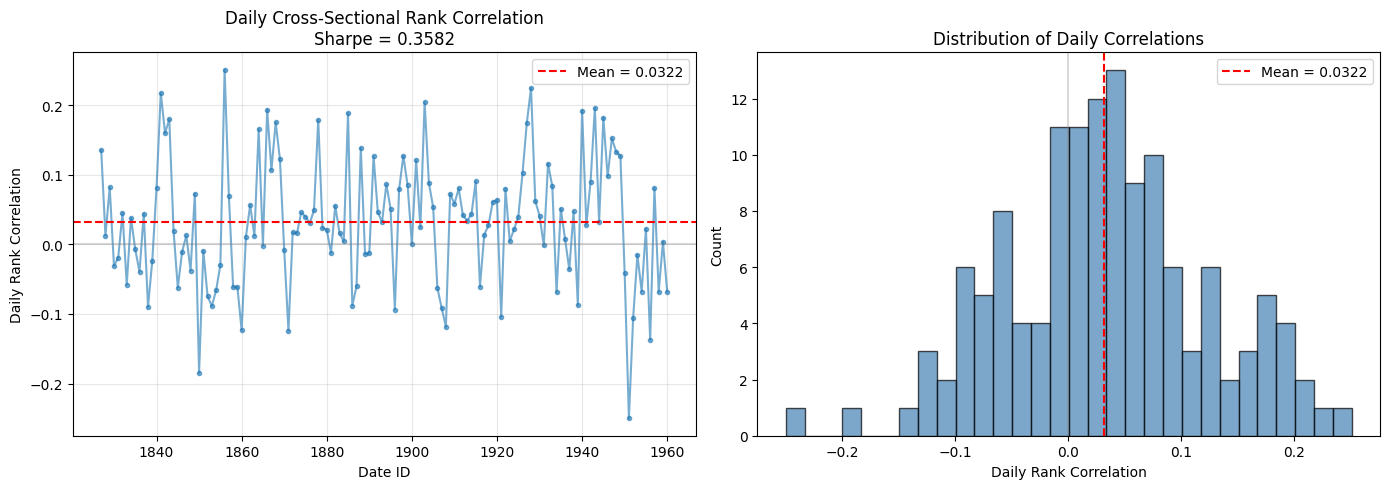

In [15]:
# %% ============================================================
# CELL 14: Visualize
# ===============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].plot(valid_date_ids[:len(daily_all)], daily_all, marker=".", alpha=0.6)
axes[0].axhline(daily_all.mean(), color="red", linestyle="--",
                label=f"Mean = {daily_all.mean():.4f}")
axes[0].axhline(0, color="gray", linestyle="-", alpha=0.3)
axes[0].set_xlabel("Date ID")
axes[0].set_ylabel("Daily Rank Correlation")
axes[0].set_title(f"Daily Cross-Sectional Rank Correlation\nSharpe = {sharpe_all:.4f}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
 
axes[1].hist(daily_all, bins=30, edgecolor="black", alpha=0.7, color="steelblue")
axes[1].axvline(daily_all.mean(), color="red", linestyle="--",
                label=f"Mean = {daily_all.mean():.4f}")
axes[1].axvline(0, color="gray", linestyle="-", alpha=0.3)
axes[1].set_xlabel("Daily Rank Correlation")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Daily Correlations")
axes[1].legend()
 
plt.tight_layout()
plt.savefig("daily_correlations_v3.png", dpi=150)
plt.show()

In [16]:
# %% ============================================================
# CELL 15: Save Everything
# ===============================================================
pred_df.to_csv("predictions_lstm_v3.csv", index=False)
 
for s, model in enumerate(models):
    torch.save(model.state_dict(), f"model_v3_seed{s}.pt")
 
config = {
    "SEQUENCE_LENGTH": SEQUENCE_LENGTH, "HIDDEN_SIZE": HIDDEN_SIZE,
    "NUM_LAYERS": NUM_LAYERS, "DROPOUT": DROPOUT,
    "LEARNING_RATE": LEARNING_RATE, "WEIGHT_DECAY": WEIGHT_DECAY,
    "N_PCA": N_PCA, "RANK_LOSS_ALPHA": RANK_LOSS_ALPHA,
    "TRAIN_END": TRAIN_END, "VAL_END": VAL_END,
    "N_SEEDS": N_SEEDS, "N_TEST_DATES": n_test_dates,
    "sharpe_all": float(sharpe_all), "sharpe_scored": float(sharpe_scored),
}
pd.Series(config).to_json("config_v3.json")
 
print(f"\nSaved predictions ({pred_df.shape}), {N_SEEDS} models, and config")
print(f"\n{'='*55}")
print(f"  PREDICTIONS:  {n_test_dates} dates ({valid_date_ids.min()}-{valid_date_ids.max()})")
print(f"  FINAL SCORE (all dates):   {sharpe_all:.4f}")
print(f"  FINAL SCORE (scored only): {sharpe_scored:.4f}")
print(f"{'='*55}")


Saved predictions ((134, 425)), 5 models, and config

  PREDICTIONS:  134 dates (1827-1960)
  FINAL SCORE (all dates):   0.3582
  FINAL SCORE (scored only): 0.3615


In [17]:
# %% ============================================================
# Save Complete Model State for Exact Replication
# ===============================================================
import pickle
import joblib

save_dir = Path("saved_model_035")
save_dir.mkdir(exist_ok=True)

# 1. Save all trained model weights
for s, model in enumerate(models):
    torch.save(model.state_dict(), save_dir / f"model_seed{s}.pt")
print(f"Saved {len(models)} model state dicts")

# 2. Save scaler and PCA (needed to transform features the same way)
joblib.dump(scaler, save_dir / "scaler.joblib")
joblib.dump(pca, save_dir / "pca.joblib")
print("Saved scaler and PCA")

# 3. Save the config so we know exactly what was used
config = {
    "SEQUENCE_LENGTH": SEQUENCE_LENGTH,
    "HIDDEN_SIZE": HIDDEN_SIZE,
    "NUM_LAYERS": NUM_LAYERS,
    "DROPOUT": DROPOUT,
    "LEARNING_RATE": LEARNING_RATE,
    "WEIGHT_DECAY": WEIGHT_DECAY,
    "EPOCHS": EPOCHS,
    "BATCH_SIZE": BATCH_SIZE,
    "PATIENCE": PATIENCE,
    "N_PCA": N_PCA,
    "N_SEEDS": N_SEEDS,
    "TRAIN_END": TRAIN_END,
    "VAL_END": VAL_END,
    "RANK_LOSS_ALPHA": RANK_LOSS_ALPHA,
    "n_test_dates": 134,
}
pd.Series(config).to_json(save_dir / "config.json")
print("Saved config")

# 4. Save predictions
pred_df.to_csv(save_dir / "predictions_test.csv", index=False)
print("Saved test predictions")

# 5. Save the feature column order (critical for replication)
pd.Series(eng_cols).to_json(save_dir / "eng_cols.json")
print("Saved feature column order")

# 6. Save the seeds used
seeds_used = [42 + i * 111 for i in range(N_SEEDS)]
pd.Series(seeds_used).to_json(save_dir / "seeds.json")
print(f"Seeds used: {seeds_used}")

print(f"\nAll files saved to {save_dir}/")
print("To reload and generate identical predictions, use the cell below.")

Saved 5 model state dicts
Saved scaler and PCA
Saved config
Saved test predictions
Saved feature column order
Seeds used: [42, 153, 264, 375, 486]

All files saved to saved_model_035/
To reload and generate identical predictions, use the cell below.


In [21]:
# %% ============================================================
# Reload Saved Model and Generate Identical Predictions
# ===============================================================
# Uncomment and run this cell to reload the exact model state
# and verify it produces the same predictions.

load_dir = Path("saved_model_035")

# Load config
config = pd.read_json(load_dir / "config.json", typ="series").to_dict()
print("Config:", config)

# Load scaler and PCA
scaler_loaded = joblib.load(load_dir / "scaler.joblib")
pca_loaded = joblib.load(load_dir / "pca.joblib")

# Rebuild features (must use same engineer_features function)
train_feat_reload = lstm_engineer_features(train) if 'lstm_engineer_features' in dir() else engineer_features(train, target_pairs)
eng_cols_reload = pd.read_json(load_dir / "eng_cols.json", typ="series").tolist()

scaled_reload = np.clip(scaler_loaded.transform(train_feat_reload[eng_cols_reload]).astype(np.float32), -5, 5)
pca_reload = pca_loaded.transform(scaled_reload).astype(np.float32)

# Load models and predict
n_seeds = int(config["N_SEEDS"])
seq_len = int(config["SEQUENCE_LENGTH"])
n_pca = int(config["N_PCA"])
n_targets = len(target_cols)
test_start_idx_r = train[train["date_id"] == 1827].index[0]

reload_preds = []
for s in range(n_seeds):
    model_r = LSTMRanker(n_pca, n_targets, int(config["HIDDEN_SIZE"]),
                          int(config["NUM_LAYERS"]), config["DROPOUT"]).to(DEVICE)
    model_r.load_state_dict(torch.load(load_dir / f"model_seed{s}.pt", map_location=DEVICE))
    model_r.eval()
    preds = []
    with torch.no_grad():
        for i in range(test_start_idx_r, test_start_idx_r + 134):
            x = pca_reload[i - seq_len:i]
            x_t = torch.FloatTensor(x).unsqueeze(0).to(DEVICE)
            preds.append(model_r(x_t).cpu().numpy()[0])
    reload_preds.append(np.array(preds))

reload_ensemble = np.mean(reload_preds, axis=0)
reload_df = pd.DataFrame(reload_ensemble, columns=target_cols)
reload_df.insert(0, "date_id", train["date_id"].values[test_start_idx_r:test_start_idx_r+134])

# Verify identical
original = pd.read_csv(load_dir / "predictions_test.csv")
diff = np.abs(reload_df[target_cols].values - original[target_cols].values).max()
print(f"Max difference from saved predictions: {diff:.15f}")
if diff < 1e-6:
    print("SUCCESS: Predictions are identical!")
else:
    print("WARNING: Predictions differ — check feature engineering function")

# Score the reloaded predictions
gt_aligned = ground_truth[ground_truth["date_id"].isin(reload_df["date_id"])].sort_values("date_id").reset_index(drop=True)
reload_aligned = reload_df[reload_df["date_id"].isin(gt_aligned["date_id"])].sort_values("date_id").reset_index(drop=True)

print("\nReloaded model score:")
competition_score(reload_aligned, gt_aligned, target_cols)

Config: {'SEQUENCE_LENGTH': 20.0, 'HIDDEN_SIZE': 32.0, 'NUM_LAYERS': 1.0, 'DROPOUT': 0.4, 'LEARNING_RATE': 0.0005, 'WEIGHT_DECAY': 0.001, 'EPOCHS': 200.0, 'BATCH_SIZE': 64.0, 'PATIENCE': 35.0, 'N_PCA': 100.0, 'N_SEEDS': 5.0, 'TRAIN_END': 1600.0, 'VAL_END': 1827.0, 'RANK_LOSS_ALPHA': 0.7000000000000001, 'n_test_dates': 134.0}
Max difference from saved predictions: 0.000000009201333
SUCCESS: Predictions are identical!

Reloaded model score:
  Daily rank corr: mean=0.0322, std=0.0898, Sharpe=0.3582, days=134


(np.float64(0.35821700949154517),
 array([ 0.13520458,  0.01245252,  0.0818065 , -0.03104447, -0.01895955,
         0.04498453, -0.05789816,  0.03786573, -0.00737841, -0.03949135,
         0.04409096, -0.08980857, -0.02376449,  0.08103966,  0.21730108,
         0.15984391,  0.17963423,  0.01975642, -0.06253888, -0.01090668,
         0.01273729, -0.0377785 ,  0.07283223, -0.184802  , -0.00933894,
        -0.07476489, -0.08849064, -0.066019  , -0.02987917,  0.25099362,
         0.06969199, -0.06133138, -0.06097748, -0.12345259,  0.01053817,
         0.05649483,  0.01216946,  0.16542817, -0.00184145,  0.19334956,
         0.10660685,  0.17509294,  0.12247728, -0.00800595, -0.12420966,
         0.01744209,  0.0156603 ,  0.04578207,  0.03984808,  0.03039444,
         0.04913201,  0.17852331,  0.02374336,  0.02110815, -0.01243158,
         0.05526751,  0.01617572,  0.00414717,  0.18853158, -0.08795932,
        -0.06046034,  0.13839844, -0.01413342, -0.0128896 ,  0.12657403,
         0.046395